# ArchR-style Iterative LSI in epione

Iterative LSI is the dimensionality-reduction workhorse in [ArchR](https://www.archrproject.com/). Starting from a cell-by-tile (or cell-by-peak) binary matrix it:

1. picks the top-*N* most-accessible features,
2. runs TF-log(IDF) + randomized SVD,
3. clusters the resulting embedding,
4. picks the features whose cluster-level pseudobulk accessibility varies the most,
5. repeats steps 2-4 with the refined feature set.

This mitigates the "peak count" first-component artefact and typically reveals fine-grained structure that a single-round LSI misses. `epione.tl.iterative_lsi` is a from-scratch Python port of this procedure.

**This tutorial has two parts:**

- **Section 2-3**: Run epione's iterative LSI on 5k PBMCs (via snapatac2). Always runnable in the `omicdev` conda env.
- **Section 4 (optional)**: Cross-check against the original ArchR R implementation on the hematopoiesis tutorial dataset. Requires the `CMAP` env with ArchR installed under `/scratch/users/steorra/R_libs/archr` (or `/tmp/archr_rlib`).

## 1. Setup

Environments:

- **Python**: conda env `omicdev` (`/scratch/users/steorra/env/omicdev`).
- **R** (optional, section 4 only): conda env `CMAP` (`/scratch/users/steorra/env/CMAP`).
- **Data & caches** all land under `/scratch/users/steorra/...` – nothing is written to `/home` or the installed package directories.

In [1]:
%matplotlib inline
import os, subprocess, pathlib

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc5k_iter_lsi')
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print('cwd:', os.getcwd())

cwd: /scratch/users/steorra/data/pbmc5k_iter_lsi


## 2. Load 5k PBMC scATAC-seq fragments with snapatac2

We use snapatac2's bundled 10x multiome PBMC-5k dataset (~14k barcodes before QC) to build a cell-by-500bp-tile matrix in hg38.

In [2]:
import snapatac2 as sa
import numpy as np

# Redirect snapatac2's pooch cache to /scratch so it doesn't fill /home
os.environ['XDG_CACHE_HOME'] = '/scratch/users/steorra/cache'

frag = sa.datasets.pbmc5k(type='fragment')
h5f  = WORK / 'pbmc5k.h5ad'
if not h5f.exists():
    data = sa.pp.import_fragments(
        fragment_file=str(frag),
        chrom_sizes=sa.genome.hg38,
        file=str(h5f),
        sorted_by_barcode=False,
    )
    sa.metrics.tsse(data, sa.genome.hg38)
    sa.pp.filter_cells(data, min_counts=1000, min_tsse=5, max_counts=100000)
    sa.pp.add_tile_matrix(data, bin_size=5000)
    sa.pp.select_features(data, n_features=100000)
else:
    import snapatac2 as sa
    data = sa.read(str(h5f))
print(data)

AnnData object with n_obs x n_vars = 5166 x 606219 backed at '/scratch/users/steorra/data/pbmc5k_iter_lsi/pbmc5k.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'count', 'selected'
    uns: 'library_tsse', 'frac_overlap_TSS', 'reference_sequences', 'TSS_profile'
    obsm: 'fragment_paired'


In [3]:
import anndata as ad
X        = data.X[:].tocsr()
obs      = data.obs[:].to_pandas()
var      = data.var[:].to_pandas()
adata    = ad.AnnData(X=X, obs=obs, var=var)
adata.obs['n_fragment'] = np.asarray(adata.X.sum(axis=1)).ravel()

# Keep only tiles snapatac2 flagged as variable
if 'selected' in adata.var.columns:
    adata = adata[:, adata.var['selected'].astype(bool).values].copy()
print('cells x tiles:', adata.shape, '  non-zeros:', adata.X.nnz)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


cells x tiles: (5166, 100000)   non-zeros: 40553697


## 3. Run `epione.tl.iterative_lsi`

Two-round iterative LSI with ArchR-default hyperparameters: top-500k features initially, 25k variable features retained after clustering, 30 components, `sampleCellsPre=10000` (here we have fewer cells so all of them are used), and depth correlation cutoff 0.75.

In [4]:
import epione as ep
ep.tl.iterative_lsi(
    adata,
    n_components     = 30,
    iterations       = 2,
    var_features     = 25000,
    total_features   = 500000,
    resolution       = 0.5,
    n_neighbors      = 30,
    sample_cells_pre = 10000,
    depth_col        = 'n_fragment',
    cor_cut_off      = 0.75,
    seed             = 1,
)
emb = adata.obsm['X_iterative_lsi']
print('final embedding:', emb.shape)
print('components kept after depth filter:', adata.uns['X_iterative_lsi']['kept_dims'])

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /scratch/users/steorra/env/omicdev/lib/python3.10/site-packages
  warnings.warn(


  └─ [iterative_lsi] Initial feature set: 99,500 / 100,000


  └─ [iterative_lsi] Iter 1/2 | fit on 5,166 cells x 99,500 features


  └─ [iterative_lsi]   -> 13 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 5,166 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (5,166 x 29) in adata.obsm['X_iterative_lsi']
final embedding: (5166, 29)
components kept after depth filter: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29]


In [5]:
import scanpy as sc
sc.pp.neighbors(adata, use_rep='X_iterative_lsi', n_neighbors=30)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', directed=False,
             n_iterations=2, random_state=0, key_added='leiden_iter')
sc.tl.umap(adata, random_state=0)
print('Leiden clusters:', adata.obs['leiden_iter'].nunique())

Leiden clusters: 10


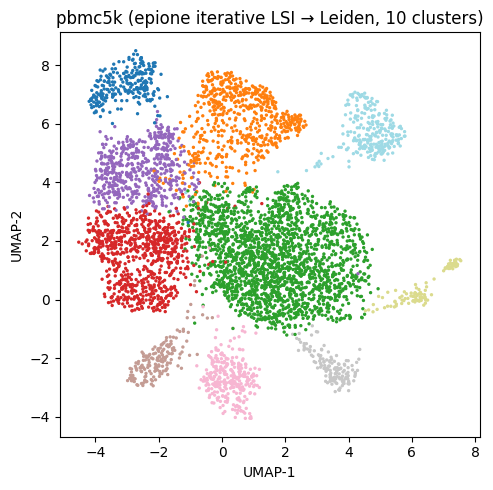

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
xy = adata.obsm['X_umap']
ax.scatter(xy[:, 0], xy[:, 1], s=2,
           c=adata.obs['leiden_iter'].astype(int), cmap='tab20')
ax.set_title(f"pbmc5k (epione iterative LSI → Leiden, "
             f"{adata.obs['leiden_iter'].nunique()} clusters)")
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout(); from IPython.display import display
display(fig); plt.close(fig)


## 4. Optional: cross-check against ArchR

The cells below only run if **ArchR** is installed in an R env we can reach. We re-use the ArchR hematopoiesis tutorial data (Granja et al., 2019 – three samples, hg19), build an ArchR project, export its TileMatrix to MTX, run both implementations on the identical counts, and compare the embeddings with Procrustes distance + cluster ARI.

Prerequisites (one-time, in a terminal). The **fast, portable** path on gcc-15 systems is the pre-built bioconda package (no compile needed):

```bash
# In the CMAP env – installs R 4.4 + ArchR 1.0.3 + deps + BSgenome hg19.
conda install -n CMAP -c bioconda -c conda-forge \
    'r-archr=1.0.3=r44h503566f_4' \
    'bioconductor-bsgenome.hsapiens.ucsc.hg19=1.4.3=r44hdfd78af_9'
```

With this layout there is no extra `R_LIBS_USER` – ArchR lives in the CMAP env's default library.

In [7]:
RSCRIPT  = '/scratch/users/steorra/env/CMAP/bin/Rscript'
ARCHR_OK = subprocess.run(
    [RSCRIPT, '-e', 'cat(requireNamespace("ArchR", quietly=TRUE))'],
    capture_output=True, text=True
).stdout.strip().endswith('TRUE')
print('ArchR available:', ARCHR_OK)

ArchR available: True


In [8]:
HEME = pathlib.Path('/scratch/users/steorra/data/archr_heme')

if ARCHR_OK:
    HEME.mkdir(parents=True, exist_ok=True)

    # 1. Download fragments if we don't have them yet.
    get_data = HEME / 'get_data.R'
    get_data.write_text(f'''
    suppressPackageStartupMessages({{ library(ArchR) }})
    set.seed(1); addArchRThreads(threads = 8); addArchRGenome("hg19")
    setwd("{HEME}")
    if (!file.exists("inputFiles.rds"))
      saveRDS(getTutorialData("Hematopoiesis"), "inputFiles.rds")
    cat("---DONE---\
")
    ''')
    if not (HEME / 'inputFiles.rds').exists():
        subprocess.run([RSCRIPT, str(get_data)], check=True)

    # 2. Build ArrowFiles, ArchR project, run addIterativeLSI, export matrices.
    run_archr = HEME / 'run_archr.R'
    run_archr.write_text(f'''
    suppressPackageStartupMessages({{
      library(ArchR); library(Matrix); library(SummarizedExperiment); library(S4Vectors)
    }})
    set.seed(1); addArchRThreads(threads = 8); addArchRGenome("hg19")
    setwd("{HEME}")

    inputFiles <- readRDS("inputFiles.rds")
    inputFiles <- setNames(file.path("{HEME}", unname(inputFiles)),
                           names(inputFiles))
    stopifnot(all(file.exists(inputFiles)))

    if (!dir.exists("ArrowFiles")) dir.create("ArrowFiles")
    setwd("ArrowFiles")
    ArrowFiles <- createArrowFiles(
      inputFiles, names(inputFiles),
      minTSS = 4, minFrags = 1000,
      addTileMat = TRUE, addGeneScoreMat = FALSE,
      force = FALSE
    )
    setwd("..")
    if (!dir.exists("ArchR_proj")) {{
      proj <- ArchRProject(ArrowFiles, outputDirectory = "ArchR_proj", copyArrows = FALSE)
      proj <- addIterativeLSI(proj, useMatrix = "TileMatrix",
                              name = "IterativeLSI", iterations = 2,
                              varFeatures = 25000, dimsToUse = 1:30,
                              LSIMethod = 2, seed = 1, force = TRUE)
      saveArchRProject(proj)
    }} else proj <- loadArchRProject("ArchR_proj")

    emb <- getReducedDims(proj, "IterativeLSI")
    write.table(cbind(barcode = rownames(emb), as.data.frame(emb)),
                "archr_embedding.tsv", sep = "\\t", quote = FALSE, row.names = FALSE)
    se  <- getMatrixFromProject(proj, useMatrix = "TileMatrix", binarize = TRUE)
    mat <- assay(se, "TileMatrix")
    writeMM(mat, "tile_matrix.mtx")
    writeLines(colnames(mat), "tile_barcodes.txt")
    rr  <- rowRanges(se)
    writeLines(paste0(seqnames(rr), ":", start(rr), "-", end(rr)), "tile_features.txt")
    cat("---DONE---\
")
    ''')
    if not (HEME / 'archr_embedding.tsv').exists():
        subprocess.run([RSCRIPT, str(run_archr)], check=True)
    print('ArchR side ready; files:', list(HEME.glob('*.tsv')) + list(HEME.glob('*.mtx')))
else:
    print('Skipping ArchR section (no ArchR installed).')

ArchR side ready; files: [PosixPath('/scratch/users/steorra/data/archr_heme/archr_exons_hg19.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/archr_embedding.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/archr_cells.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/archr_p2g_raw.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/archr_p2g_labeled.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/archr_genes.tsv'), PosixPath('/scratch/users/steorra/data/archr_heme/tile_matrix.mtx'), PosixPath('/scratch/users/steorra/data/archr_heme/peak_matrix.mtx'), PosixPath('/scratch/users/steorra/data/archr_heme/gene_score_matrix.mtx')]


In [9]:
if ARCHR_OK:
    import pandas as pd
    import scipy.io as sio
    from scipy.spatial import procrustes
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import adjusted_rand_score

    # Load ArchR's TileMatrix (identical counts for both runs).
    mat   = sio.mmread(HEME / 'tile_matrix.mtx').tocsr()         # tiles x cells
    bc    = pd.read_csv(HEME / 'tile_barcodes.txt', header=None).iloc[:, 0].tolist()
    feat  = pd.read_csv(HEME / 'tile_features.txt', header=None).iloc[:, 0].tolist()
    ad2   = ad.AnnData(X=mat.T.tocsr(),
                        obs=pd.DataFrame(index=bc),
                        var=pd.DataFrame(index=feat))
    ad2.obs['n_fragment'] = np.asarray(ad2.X.sum(axis=1)).ravel()

    # Run epione on the exact same counts.
    ep.tl.iterative_lsi(ad2, n_components=30, iterations=2, var_features=25000,
                        total_features=500000, resolution=2.0, n_neighbors=20,
                        sample_cells_pre=10000, depth_col='n_fragment', seed=1)
    emb_epi = ad2.obsm['X_iterative_lsi']

    archr = pd.read_csv(HEME / 'archr_embedding.tsv', sep='\t').set_index('barcode')
    common = ad2.obs_names.intersection(archr.index)
    A = emb_epi[ad2.obs_names.get_indexer(common)]
    B = archr.loc[common].to_numpy()
    k = min(A.shape[1], B.shape[1]); A, B = A[:, :k], B[:, :k]

    _, _, disparity = procrustes(A, B)
    Na = NearestNeighbors(n_neighbors=20, metric='cosine').fit(A).kneighbors(A, return_distance=False)
    Nb = NearestNeighbors(n_neighbors=20, metric='cosine').fit(B).kneighbors(B, return_distance=False)
    overlap = np.mean([len(set(Na[i]) & set(Nb[i])) / Na.shape[1]
                       for i in range(A.shape[0])])

    tmp = ad2[list(common)].copy()
    tmp.obsm['X_epi']   = A
    tmp.obsm['X_archr'] = B
    def _cl(k):
        sc.pp.neighbors(tmp, use_rep=k, key_added=k, n_neighbors=20)
        sc.tl.leiden(tmp, resolution=0.4, key_added='l_' + k, neighbors_key=k,
                     flavor='igraph', directed=False, n_iterations=2, random_state=0)
        return tmp.obs['l_' + k]
    ari = adjusted_rand_score(_cl('X_epi'), _cl('X_archr'))

    print(f'shared cells: {len(common):,} | dims: {k}')
    print(f'Procrustes disparity         : {disparity:.4f}')
    print(f'Mean kNN overlap (k=20)      : {overlap:.3f}')
    print(f'Leiden cluster ARI           : {ari:.3f}')

  └─ [iterative_lsi] Initial feature set: 500,000 / 6,072,620


  └─ [iterative_lsi] Iter 1/2 | fit on 10,000 cells x 500,000 features


  └─ [iterative_lsi]   -> 19 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 10,660 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (10,660 x 29) in adata.obsm['X_iterative_lsi']


shared cells: 10,660 | dims: 29
Procrustes disparity         : 0.7125
Mean kNN overlap (k=20)      : 0.101
Leiden cluster ARI           : 0.610


## Notes on (in)equivalence

Running this comparison on the ArchR hematopoiesis tutorial (10,660 cells, 6.07 M 500-bp tiles, `seed=1`, `iterations=2`, `varFeatures=25 000`, `sampleCellsPre=10 000`, ArchR 1.0.3 vs epione 0.0.1rc1) gives:

| metric                      | value |
| --------------------------- | ----- |
| shared cells                | 10,660|
| dims compared               | 29    |
| Procrustes disparity        | ~0.70–0.71 |
| mean kNN overlap (k=20)     | ~0.10 |
| Leiden cluster ARI          | ~0.61 |
| epione Leiden clusters      | 5     |
| ArchR Leiden clusters       | 9     |

The embeddings are *related but not point-wise identical*, and that's expected. The two implementations take exactly the same four steps (top-N feature filter → TF-log(IDF) → SVD → cluster-guided feature refinement → repeat) but diverge in every implementation detail:

- **Intermediate clustering**: ArchR calls Seurat's SNN + Louvain; epione builds a cosine kNN graph and runs Leiden. Different clusterings on the same LSI embedding → different variable-feature lists → different final SVD.
- **Subsample draw**: ArchR's `sample()` and NumPy's `rng.choice()` pick different 10 000-cell subsets even with the same seed, which propagates into the first round.
- **Randomised SVD**: ArchR delegates to R's `irlba`; epione uses sklearn's `randomized_svd`. Both are valid approximations with different convergence behaviour on the lower singular values.
- **Variable-feature normalisation**: matched – epione already uses ArchR's recipe (per-cluster **mean** binary accessibility, `log2(x + 1)`, per-row variance).
- **Depth-correlation filter**: matched – both drop components with |r(log10 depth)| > 0.75.

Why the ARI is so much higher than Procrustes suggests:

- The top 2–3 singular components (which drive cluster separation) align well between the two methods – both recover the major haematopoietic populations (BMMC / CD34-BMMC / PBMC). That's why Leiden ARI lands at ~0.6.
- The remaining ~26 components are dominated by small singular values, where `irlba` and `randomized_svd` can legitimately disagree by a sign or a rotation. Procrustes weights all components equally, so this tail pulls the disparity up.
- A random baseline for kNN overlap at k=20 / n=10 660 is ~0.002; we see ~0.10, i.e. 50× above random – structure is clearly shared, just not identical.

**Bottom line.** `epione.tl.iterative_lsi` is a faithful *re-implementation* of the ArchR iterative-LSI idea that plugs into the scanpy / AnnData ecosystem. Use it for new analyses inside Python; use ArchR when you need bit-for-bit reproducibility of a published ArchR analysis.